In [2]:
from typing import Literal
import pickle
from pathlib import Path
from copy import deepcopy

import time
from sklearn.datasets import make_blobs
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    SpectralClustering,
    DBSCAN,
    OPTICS,
    Birch,
    MeanShift,
    AffinityPropagation,
    MiniBatchKMeans,
    HDBSCAN,
    BisectingKMeans
)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from memory_profiler import profile
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import numpy as np
import tracemalloc

In [2]:
def generate_vectors(n_vectors=1000, dimensions=32, mean=0, std=1):
    """
    Generate a specified number of random vectors with a given dimensionality from a normal distribution.

    Parameters:
    n_vectors (int): Number of vectors to generate.
    dimensions (int): Dimensionality of each vector.
    mean (float): Mean of the normal distribution.
    std (float): Standard deviation of the normal distribution.

    Returns:
    np.ndarray: An array of shape (n_vectors, dimensions) containing the generated vectors.
    """
    return np.random.normal(loc=mean, scale=std, size=(n_vectors, dimensions))


def test_function_performance(vectors, algorithm):
    t_alg = deepcopy(algorithm)
    start_time = time.time()

    tracemalloc.start()

    t_alg.fit(vectors)

    _, memory_usage = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    end_time = time.time()
    exec_time = end_time - start_time

    return (t_alg.labels_, exec_time, memory_usage / 10**6)


def show_clusters(
    vectors, marks=None, dementions_reduction_algorithm: Literal["tsne", "pca"] = "tsne"
):
    if dementions_reduction_algorithm == "tsne":
        X = TSNE(n_components=2).fit_transform(vectors)
    elif dementions_reduction_algorithm == "pca":
        X = PCA(n_components=2).fit_transform(vectors)
    else:
        raise ValueError(
            "Invalid dementions_reduction_algorithm. Choose 'tsne' or 'pca'."
        )
    if marks is None:
        marks = [0] * len(vectors)
    plt.scatter(X[:, 0], X[:, 1], c=marks, cmap="viridis")
    plt.show()

def experiment(sizes, algorithms, result_path="results.pkl", new_result=True):
    # Test each clustering algorithm
    result_path = Path("results.pkl")
    if not new_result and result_path.is_file():
        with open("results.pkl", "rb") as f:
            results = pickle.load(f)
    else:
        results = {k: {} for k in clustering_algorithms.keys()}
    pbar = tqdm(total=len(sizes) * len(clustering_algorithms) - 1)
    for s in sizes:
        vectors = generate_vectors(10**s)
        for name, algo in clustering_algorithms.items():
            pbar.set_description(f"10^{s} {name}")
            results[name][s] = test_function_performance(vectors, algo)
            pbar.update()
        with open(result_path, "wb") as f:
            pickle.dump(results, f)

In [3]:
# vectors = generate_vectors(10**8)
# show_clusters(vectors=vectors)

In [4]:
# List of clustering algorithms to test
clustering_algorithms = {
    'KMeans': KMeans(n_clusters=5),
    "MiniBatchKMeans": MiniBatchKMeans(n_clusters=5),
    # "MeanShift": MeanShift(),  -- Время работы растет пропорциионально количеству векторов уже на 10^5 больше часа считается
    # 'AffinityPropagation': AffinityPropagation(), -- Уже на 10^5 требует 74.5 GiB (N^2)
    'DBSCAN': DBSCAN(),
    # 'HDBSCAN': HDBSCAN(), -- На 10^6 Считалолось больше 17 часов
    # 'OPTICS': OPTICS(), 
    # 'SpectralClustering': SpectralClustering(n_clusters=5),  -- Уже на 10^5 требует 74.5 GiB (N^2)
    # 'AgglomerativeClustering': AgglomerativeClustering(n_clusters=5), # На 10^5 37.3 Gb
    # 'Birch': Birch(n_clusters=5),
    'BisectingKMeans': BisectingKMeans(n_clusters=5)
}

In [5]:
experiment(range(6, 9), clustering_algorithms, new_result=False)

  0%|          | 0/11 [00:00<?, ?it/s]

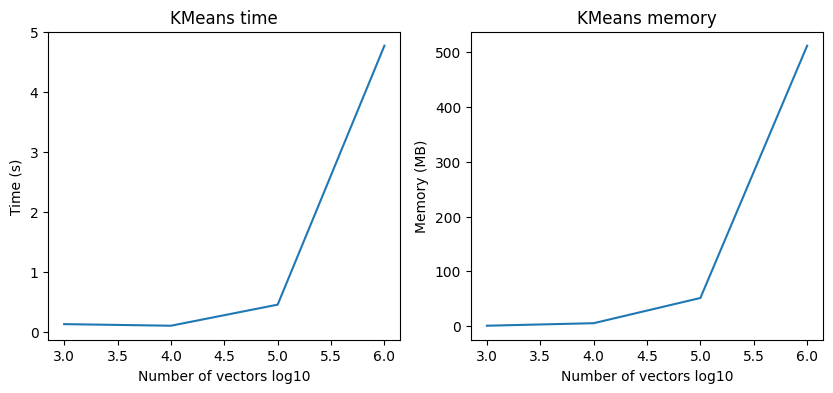

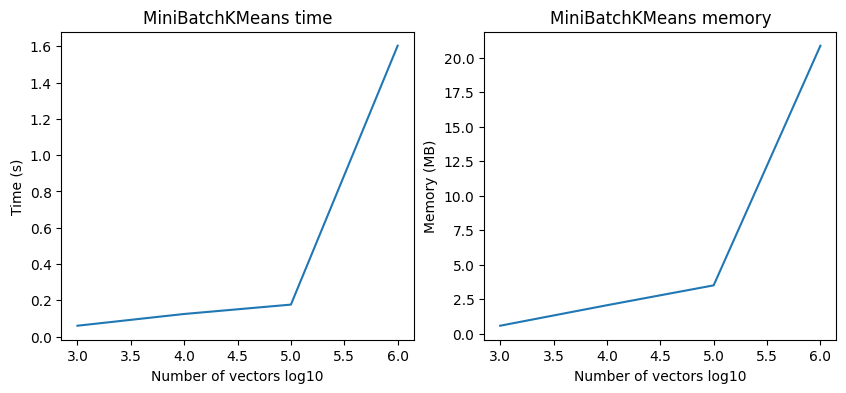

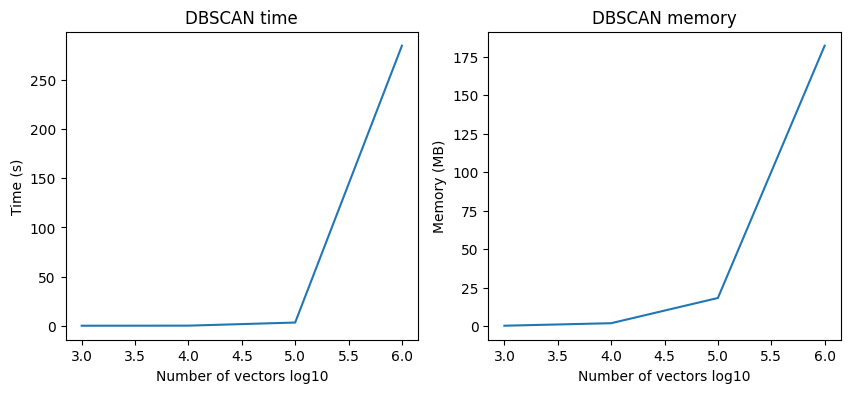

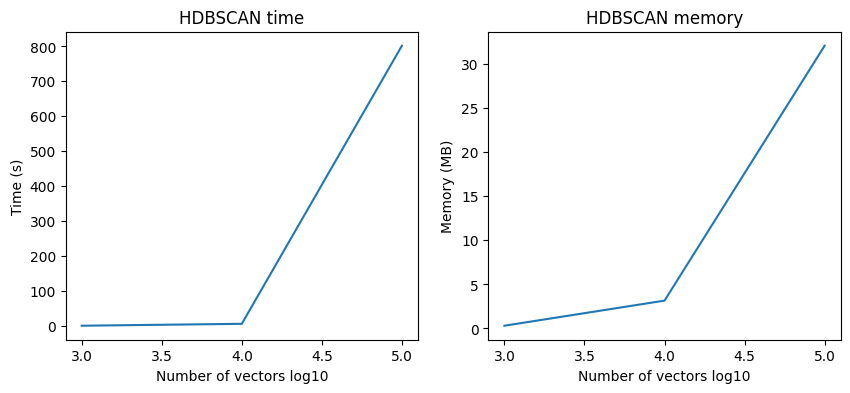

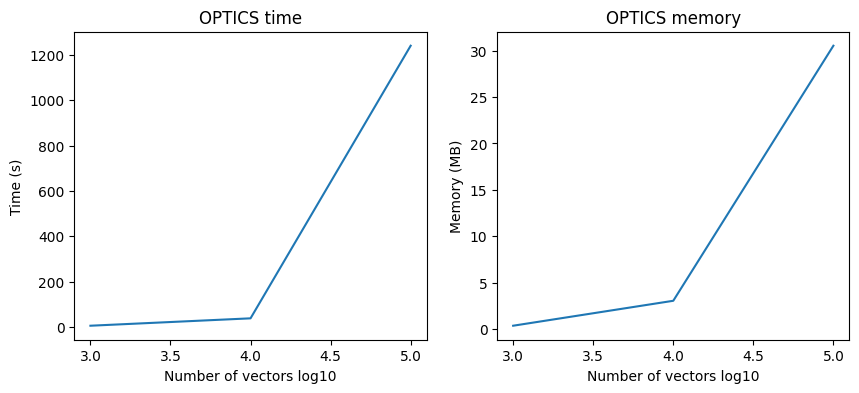

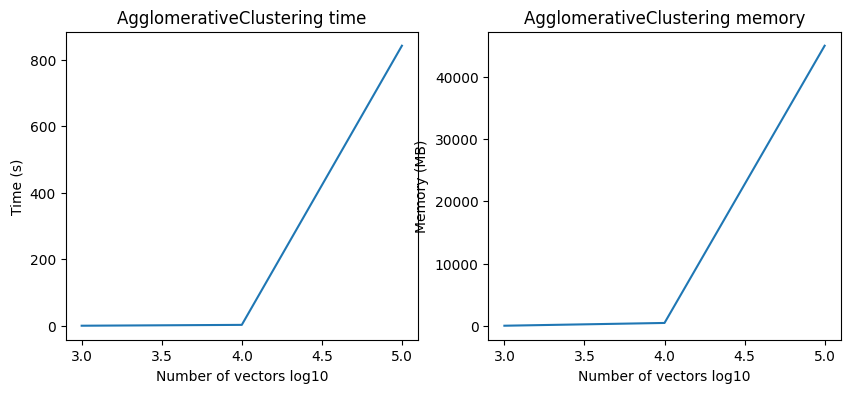

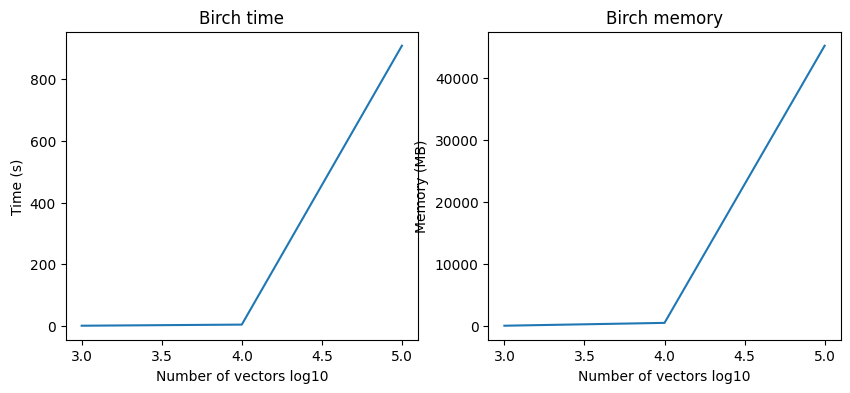

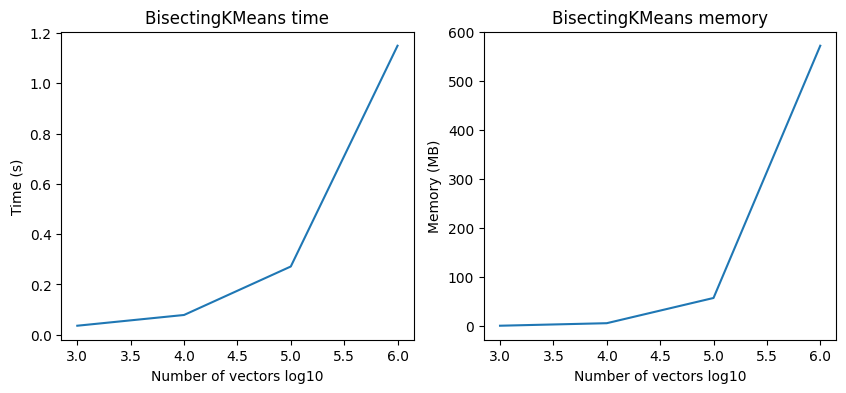

In [3]:
with open("results.pkl", "rb") as f:
    results = pickle.load(f)

for k, v in results.items():

    v = dict(sorted(v.items()))
    sizes = list(v.keys())
    times = [v[s][1] for s in sizes]
    memories = [v[s][2] for s in sizes]

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(sizes, times)
    ax[0].set_title(f"{k} time")
    ax[0].set_xlabel("Number of vectors log10")
    ax[0].set_ylabel("Time (s)")
    ax[1].plot(sizes, memories)
    ax[1].set_title(f"{k} memory")
    ax[1].set_xlabel("Number of vectors log10")
    ax[1].set_ylabel("Memory (MB)")
    plt.show()